
# 02 &nbsp;|&nbsp; Exploratory Data Analysis and Toxicity over Time

**Dissertation:** *Temporal Prediction of In-Trial Adverse Events in Oncology Clinical Trials Using Machine Learning*

---

## Purpose

This notebook characterises the cohort and — more importantly — establishes **empirically**
the premise on which the whole dissertation rests:

> Severe adverse-event risk in this trial is **not constant over time**, so a single
> baseline risk score cannot describe it adequately.

This is the *Toxicity over Time* (ToxT) argument of Thanarajasingam et al. reproduced on
the study data. Sections:

1. cohort characteristics (Table 1);
2. the adverse-event landscape (grade, term, seriousness, action taken);
3. **toxicity over time** — incidence, hazard and cumulative burden;
4. longitudinal predictors: ECOG, vital signs, dose intensity;
5. the target variable — prevalence and sensitivity to the horizon choice.

In [1]:
# --- environment setup -------------------------------------------------------
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeprep import io, quality, labels, features_static, features_temporal
from aeprep import modeling, evaluation, plots
from aeprep.config import CFG, DATASET_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, ensure_output_dirs

ensure_output_dirs()
plots.set_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"analysis config: horizon={CFG.prediction_horizon_days}d, "
      f"grade>={CFG.severity_threshold}, landmark step={CFG.landmark_step_days}d")

project root : C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root
pandas 2.3.3 | numpy 2.3.5
analysis config: horizon=30d, grade>=3, landmark step=14d


In [2]:
domains = io.load_all_domains()
timeline = pd.read_parquet(DATASET_DIR / "patient_timeline.parquet")
ae = io.tidy_adverse(domains["adverse"])
td = io.tidy_testdrug(domains["testdrug"])
vitals = io.tidy_vitals(domains["vitals"])

baseline = features_static.build_baseline_features(domains, timeline)
print(f"{len(timeline)} patients | {len(ae):,} adverse events | "
      f"{baseline.shape[1]} baseline features")

379 patients | 6,166 adverse events | 94 baseline features



## 1. Cohort characteristics (Table 1)

Stratified by whether the patient ever experienced a Grade ≥3 treatment-emergent adverse
event, which is the natural clinical dichotomy for a safety analysis.

In [3]:
te = labels.treatment_emergent_events(ae, timeline)
ever_severe = (labels.severe_events(te)
               .groupby("PID").size().rename("n_severe").reindex(timeline["PID"])
               .fillna(0).gt(0))

tab = baseline.copy()
tab["ever_severe_ae"] = ever_severe.reindex(tab.index).fillna(False).to_numpy()

def table_one(df, group_col, continuous, categorical):
    rows = []
    groups = sorted(df[group_col].unique())
    for c in continuous:
        row = {"variable": c, "type": "mean (SD)"}
        for g in groups:
            s = df.loc[df[group_col] == g, c]
            row[f"{group_col}={g}"] = f"{s.mean():.1f} ({s.std():.1f})"
        row["overall"] = f"{df[c].mean():.1f} ({df[c].std():.1f})"
        rows.append(row)
    for c in categorical:
        for level in sorted(df[c].dropna().unique()):
            row = {"variable": f"{c} = {level}", "type": "n (%)"}
            for g in groups:
                sub = df[df[group_col] == g]
                n = int((sub[c] == level).sum())
                row[f"{group_col}={g}"] = f"{n} ({100 * n / len(sub):.1f}%)"
            n = int((df[c] == level).sum())
            row["overall"] = f"{n} ({100 * n / len(df):.1f}%)"
            rows.append(row)
    return pd.DataFrame(rows)

t1 = table_one(
    tab, "ever_severe_ae",
    continuous=["age", "bmi", "bsa_m2", "weight_kg", "bl_sbp", "bl_hr",
                "n_medical_history", "n_baseline_conmeds", "months_since_diagnosis"],
    categorical=["race", "sex_male", "ecog_baseline", "age_ge_65"])
t1.to_csv(TABLE_DIR / "02_table_one.csv", index=False)
t1

,variable,type,ever_severe_ae=False,ever_severe_ae=True,overall
0,age,mean (SD),55.6 (9.7),58.7 (11.2),57.6 (10.8)
1,bmi,mean (SD),24.6 (4.7),24.9 (4.4),24.8 (4.5)
2,bsa_m2,mean (SD),1.8 (0.2),1.7 (0.2),1.8 (0.2)
3,weight_kg,mean (SD),69.2 (15.5),67.8 (14.1),68.3 (14.6)
4,bl_sbp,mean (SD),125.1 (13.5),126.3 (16.1),125.8 (15.2)
5,bl_hr,mean (SD),78.5 (10.4),78.3 (11.4),78.4 (11.0)
6,n_medical_history,mean (SD),3.0 (2.8),3.8 (3.7),3.6 (3.4)
7,n_baseline_conmeds,mean (SD),4.1 (2.8),4.7 (3.3),4.5 (3.1)
8,months_since_diagnosis,mean (SD),7.0 (11.0),12.9 (20.4),10.7 (17.8)
9,race = Asian,n (%),39 (28.5%),74 (30.6%),113 (29.8%)


In [4]:
n_sev = int(tab["ever_severe_ae"].sum())
print(f"Patients with >= 1 treatment-emergent Grade >= {CFG.severity_threshold} AE: "
      f"{n_sev} / {len(tab)} ({100 * n_sev / len(tab):.1f}%)")

Patients with >= 1 treatment-emergent Grade >= 3 AE: 242 / 379 (63.9%)



## 2. The adverse-event landscape

### 2.1 Grade, seriousness and treatment action

findfont: Failed to find font weight semibold, now using 700.


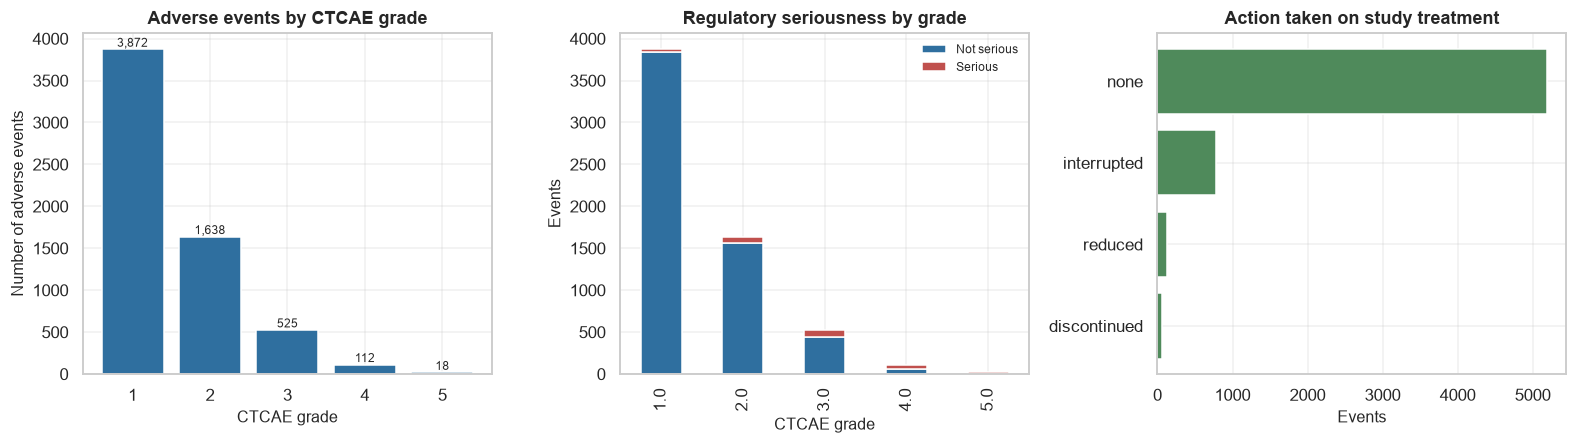

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

plots.plot_ae_grade_distribution(ae, ax=axes[0])

ser = ae.groupby(["grade", "is_serious"]).size().unstack(fill_value=0)
ser.plot(kind="bar", stacked=True, ax=axes[1],
         color=[plots.PALETTE[0], plots.PALETTE[1]])
axes[1].set(xlabel="CTCAE grade", ylabel="Events", title="Regulatory seriousness by grade")
axes[1].legend(["Not serious", "Serious"], fontsize=8)

act = ae.groupby(["dose_action"]).size().sort_values()
axes[2].barh(act.index, act.to_numpy(), color=plots.PALETTE[2])
axes[2].set(xlabel="Events", title="Action taken on study treatment")

fig.tight_layout()
plots.save(fig, "02_ae_landscape")
plt.show()

In [6]:
severe = labels.severe_events(te)
action_by_grade = (ae.assign(sev=ae["is_severe"])
                     .groupby("sev")[["led_to_reduction", "led_to_interruption",
                                      "led_to_discontinuation", "is_serious"]]
                     .mean().mul(100).round(1))
action_by_grade.index = ["Grade 1-2", f"Grade >= {CFG.severity_threshold}"]
print("Percentage of events resulting in each action:")
action_by_grade

Percentage of events resulting in each action:


,led_to_reduction,led_to_interruption,led_to_discontinuation,is_serious
Grade 1-2,0.9000,9.5000,0.4000,2.0000
Grade >= 3,12.5000,42.6000,6.4000,23.5000



Severe events are far more likely to trigger a dose interruption, reduction or permanent
discontinuation. This is the clinical cost that a forward-looking risk model is intended
to help avoid, and it justifies choosing Grade ≥3 as the target rather than "any AE".

### 2.2 Toxicity clusters

Preferred terms are grouped into clinically coherent clusters (`aeprep.config.TOXICITY_CLUSTERS`)
so that the temporal features can distinguish, for example, accumulating myelosuppression
from accumulating gastrointestinal toxicity.

In [7]:
clustered = features_temporal.assign_toxicity_clusters(te)
cluster_cols = [c for c in clustered.columns if c.startswith("cl_")]

summary = []
for c in cluster_cols:
    sub = clustered[clustered[c]]
    summary.append({
        "cluster": c.replace("cl_", ""),
        "n_events": len(sub),
        "n_severe_events": int(sub["is_severe"].sum()),
        "n_patients": sub["PID"].nunique(),
        "pct_patients": round(100 * sub["PID"].nunique() / len(timeline), 1),
        "median_first_onset_day": sub.groupby("PID")["start_day"].min().median(),
    })
cluster_tbl = pd.DataFrame(summary).sort_values("n_severe_events", ascending=False)
uncl = clustered[~clustered[cluster_cols].any(axis=1)]
print(f"{len(uncl):,} events ({100*len(uncl)/len(clustered):.0f}%) fall outside the "
      f"defined clusters and are still counted in the overall AE totals.")
cluster_tbl.to_csv(TABLE_DIR / "02_toxicity_clusters.csv", index=False)
cluster_tbl

1,898 events (31%) fall outside the defined clusters and are still counted in the overall AE totals.


,cluster,n_events,n_severe_events,n_patients,pct_patients,median_first_onset_day
0,haematologic,1024,275,234,61.7000,22.0000
1,gastrointestinal,2117,108,301,79.4000,6.0000
6,metabolic,149,46,56,14.8000,35.5000
2,constitutional,688,35,230,60.7000,32.0000
4,vascular_thrombotic,112,34,79,20.8000,72.0000
5,infection,124,25,84,22.2000,90.0000
3,hepatobiliary,54,19,28,7.4000,91.5000


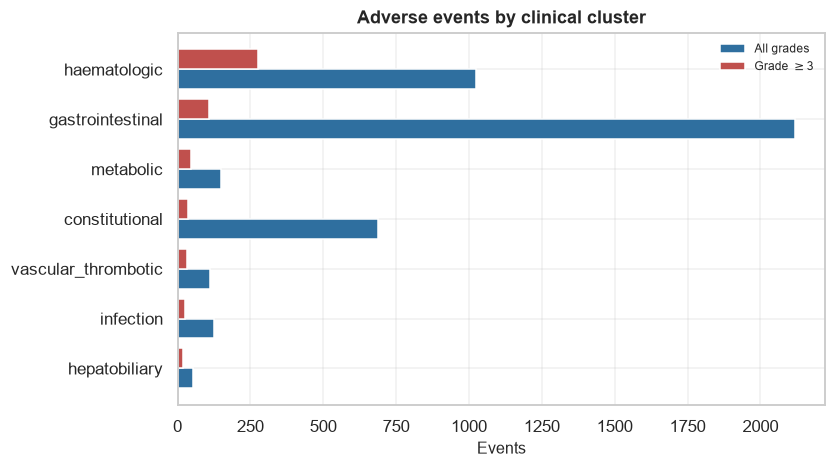

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ct = cluster_tbl.set_index("cluster")[["n_events", "n_severe_events"]].iloc[::-1]
y = np.arange(len(ct))
ax.barh(y - 0.2, ct["n_events"], height=0.4, label="All grades", color=plots.PALETTE[0])
ax.barh(y + 0.2, ct["n_severe_events"], height=0.4,
        label=f"Grade $\\geq${CFG.severity_threshold}", color=plots.PALETTE[1])
ax.set_yticks(y, ct.index)
ax.set(xlabel="Events", title="Adverse events by clinical cluster")
ax.legend(fontsize=8)
plots.save(fig, "02_toxicity_clusters")
plt.show()


## 3. Toxicity over time — the motivating evidence

A conventional safety table reports the *maximum* grade each patient ever reached. That
summary is time-blind: it cannot distinguish a patient whose severe toxicity occurred in
cycle 1 from one who deteriorated in cycle 8, and it cannot tell a monitoring team when
risk is highest.

The three views below make the time dependence explicit.

findfont: Failed to find font weight semibold, now using 700.


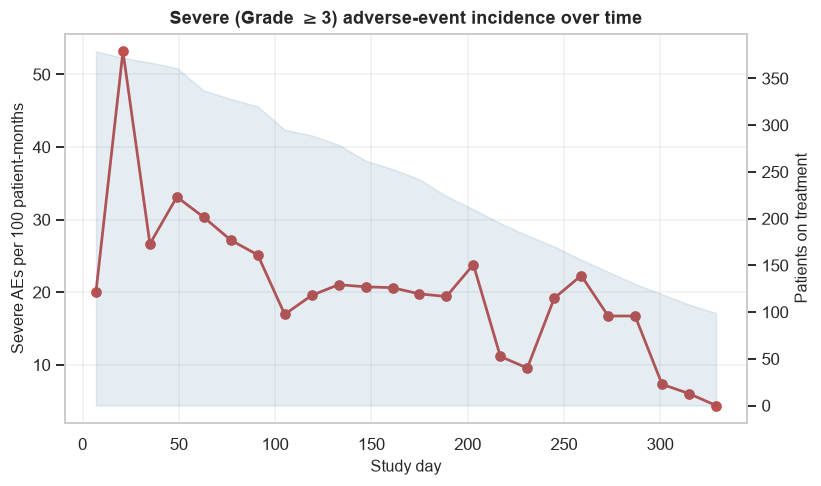

In [9]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
plots.plot_toxicity_over_time(te, timeline, bin_days=14,
                              max_day=CFG.landmark_max_day, ax=ax)
plots.save(fig, "02_toxicity_over_time")
plt.show()

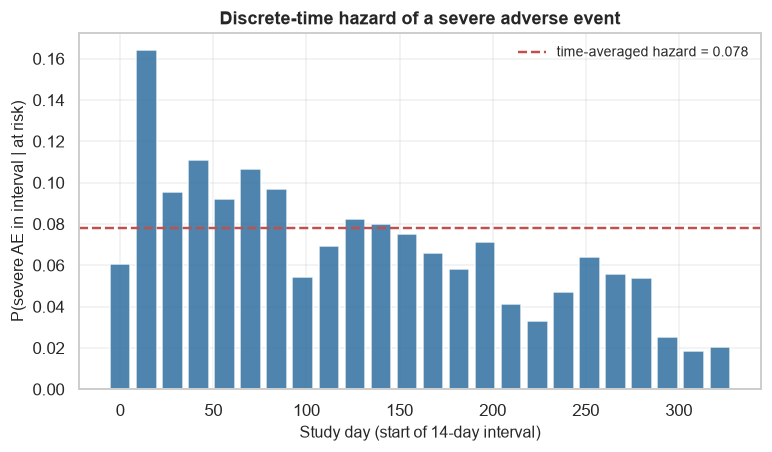

,interval_start,n_at_risk,n_patients_with_event,hazard
0,0,379,23,0.0607
1,14,372,61,0.1640
2,28,367,35,0.0954
3,42,361,40,0.1108
4,56,337,31,0.0920
5,70,328,35,0.1067
6,84,320,31,0.0969
7,98,295,16,0.0542
8,112,289,20,0.0692
9,126,279,23,0.0824


In [10]:
# Incidence per 14-day interval, expressed as a discrete-time hazard among those at risk.
bins = np.arange(0, CFG.landmark_max_day + 14, 14)
sev_days = labels.severe_events(te)[["PID", "start_day"]]

rows = []
for lo, hi in zip(bins[:-1], bins[1:]):
    at_risk = timeline[timeline["on_treatment_end"] >= lo]
    n_at_risk = len(at_risk)
    pids = set(at_risk["PID"])
    ev = sev_days[(sev_days["start_day"] > lo) & (sev_days["start_day"] <= hi)
                  & (sev_days["PID"].isin(pids))]
    rows.append({"interval_start": lo, "n_at_risk": n_at_risk,
                 "n_patients_with_event": ev["PID"].nunique(),
                 "hazard": ev["PID"].nunique() / n_at_risk if n_at_risk else np.nan})
hazard_tbl = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(hazard_tbl["interval_start"], hazard_tbl["hazard"], width=11,
       color=plots.PALETTE[0], alpha=0.85)
overall = hazard_tbl["n_patients_with_event"].sum() / hazard_tbl["n_at_risk"].sum()
ax.axhline(overall, ls="--", c=plots.PALETTE[1], lw=1.6,
           label=f"time-averaged hazard = {overall:.3f}")
ax.set(xlabel="Study day (start of 14-day interval)",
       ylabel="P(severe AE in interval | at risk)",
       title="Discrete-time hazard of a severe adverse event")
ax.legend(fontsize=9)
plots.save(fig, "02_discrete_hazard")
plt.show()

hazard_tbl.head(12)


The hazard is **not flat**: it is highest in the first two cycles and then declines, partly
because of genuine tolerance/dose adaptation and partly because the most susceptible
patients discontinue early (a depletion-of-susceptibles effect). Either way, a static
score fitted once at baseline cannot represent this.

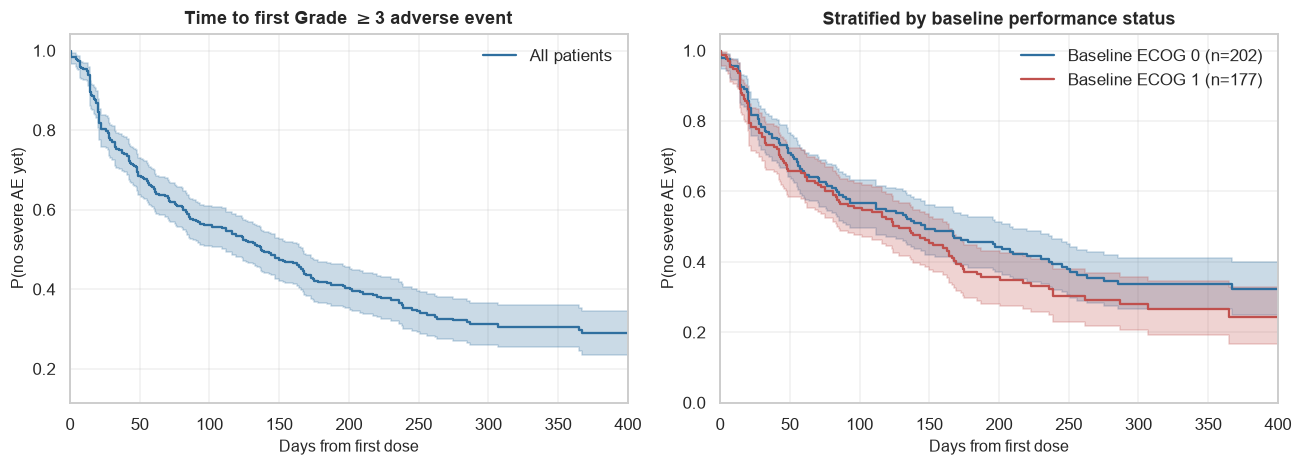

Median time to first severe AE: 137 days
Events: 242 / 379


In [11]:
from lifelines import KaplanMeierFitter

tte = labels.time_to_first_severe_ae(ae, timeline)
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))

kmf.fit(tte["duration"], tte["event"], label="All patients")
kmf.plot_survival_function(ax=axes[0], color=plots.PALETTE[0])
axes[0].set(xlabel="Days from first dose", ylabel="P(no severe AE yet)",
            title="Time to first Grade $\\geq$3 adverse event", xlim=(0, 400))

tte_ecog = tte.merge(baseline["ecog_baseline"].reset_index(), on="PID", how="left")
for val, colour in zip([0.0, 1.0], plots.PALETTE[:2]):
    sub = tte_ecog[tte_ecog["ecog_baseline"] == val]
    if len(sub) > 10:
        KaplanMeierFitter().fit(sub["duration"], sub["event"],
                                label=f"Baseline ECOG {int(val)} (n={len(sub)})"
                                ).plot_survival_function(ax=axes[1], color=colour)
axes[1].set(xlabel="Days from first dose", ylabel="P(no severe AE yet)",
            title="Stratified by baseline performance status", xlim=(0, 400))

fig.tight_layout()
plots.save(fig, "02_km_time_to_first_severe_ae")
plt.show()

print(f"Median time to first severe AE: {kmf.median_survival_time_:.0f} days")
print(f"Events: {int(tte['event'].sum())} / {len(tte)}")

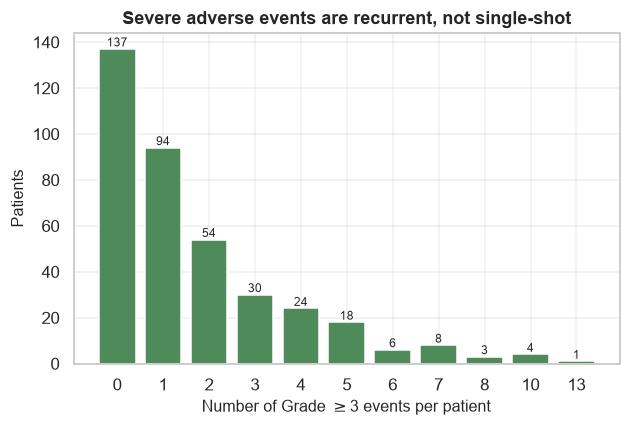

Among patients with >= 1 severe AE, median count = 2, max = 13


In [12]:
# Recurrent-event view: severe toxicity is not a one-off endpoint.
per_patient = (labels.severe_events(te).groupby("PID").size()
               .reindex(timeline["PID"]).fillna(0).astype(int))
fig, ax = plt.subplots(figsize=(6.4, 3.9))
counts = per_patient.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.to_numpy(), color=plots.PALETTE[2])
ax.set(xlabel=f"Number of Grade $\\geq${CFG.severity_threshold} events per patient",
       ylabel="Patients", title="Severe adverse events are recurrent, not single-shot")
for x, v in enumerate(counts.to_numpy()):
    ax.text(x, v, str(v), ha="center", va="bottom", fontsize=8)
plots.save(fig, "02_recurrent_severe_events")
plt.show()

print(f"Among patients with >= 1 severe AE, median count = "
      f"{per_patient[per_patient > 0].median():.0f}, max = {per_patient.max()}")


This is the second reason a survival model of the *first* event is insufficient: severe
toxicity **recurs**. A patient who had neutropenia in cycle 2 is still at risk in cycle 5,
and the clinically useful question at every point in the trial is "what happens in the
next 30 days?" — which is precisely the landmark formulation used in notebook 04.


## 4. Longitudinal predictors

### 4.1 ECOG performance status

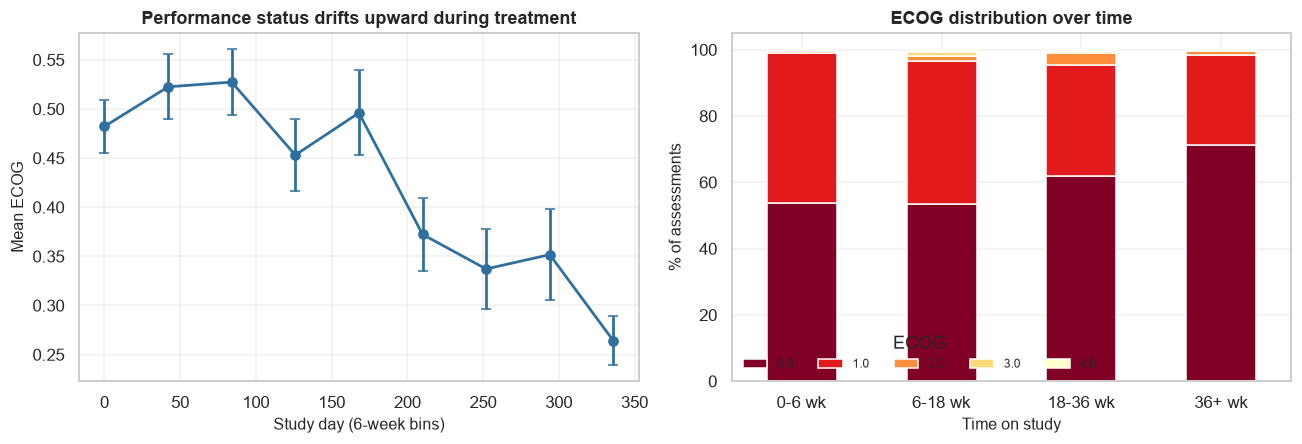

In [13]:
pfm = domains["pfm_p"].copy()
pfm["day"] = pd.to_numeric(pfm["EFDAY"], errors="coerce")
pfm["ecog"] = pd.to_numeric(pfm["PFMECOG"], errors="coerce")
pfm = pfm.dropna(subset=["day", "ecog"]).query("ecog <= 4")

pfm["bin"] = (pfm["day"] // 42 * 42).clip(0, 336)
prof = pfm[pfm["day"] >= 0].groupby("bin")["ecog"].agg(["mean", "sem", "size"])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
axes[0].errorbar(prof.index, prof["mean"], yerr=prof["sem"], marker="o",
                 lw=1.8, capsize=3, color=plots.PALETTE[0])
axes[0].set(xlabel="Study day (6-week bins)", ylabel="Mean ECOG",
            title="Performance status drifts upward during treatment")

ecog_dist = (pfm[pfm["day"] >= 0].assign(cyc=pd.cut(pfm.loc[pfm["day"] >= 0, "day"],
             [-1, 42, 126, 252, 1000], labels=["0-6 wk", "6-18 wk", "18-36 wk", "36+ wk"]))
             .groupby(["cyc", "ecog"], observed=True).size().unstack(fill_value=0))
ecog_dist = ecog_dist.div(ecog_dist.sum(axis=1), axis=0) * 100
ecog_dist.plot(kind="bar", stacked=True, ax=axes[1], colormap="YlOrRd_r")
axes[1].set(xlabel="Time on study", ylabel="% of assessments",
            title="ECOG distribution over time")
axes[1].legend(title="ECOG", fontsize=8, ncol=5)
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plots.save(fig, "02_ecog_over_time")
plt.show()


### 4.2 Vital signs and weight

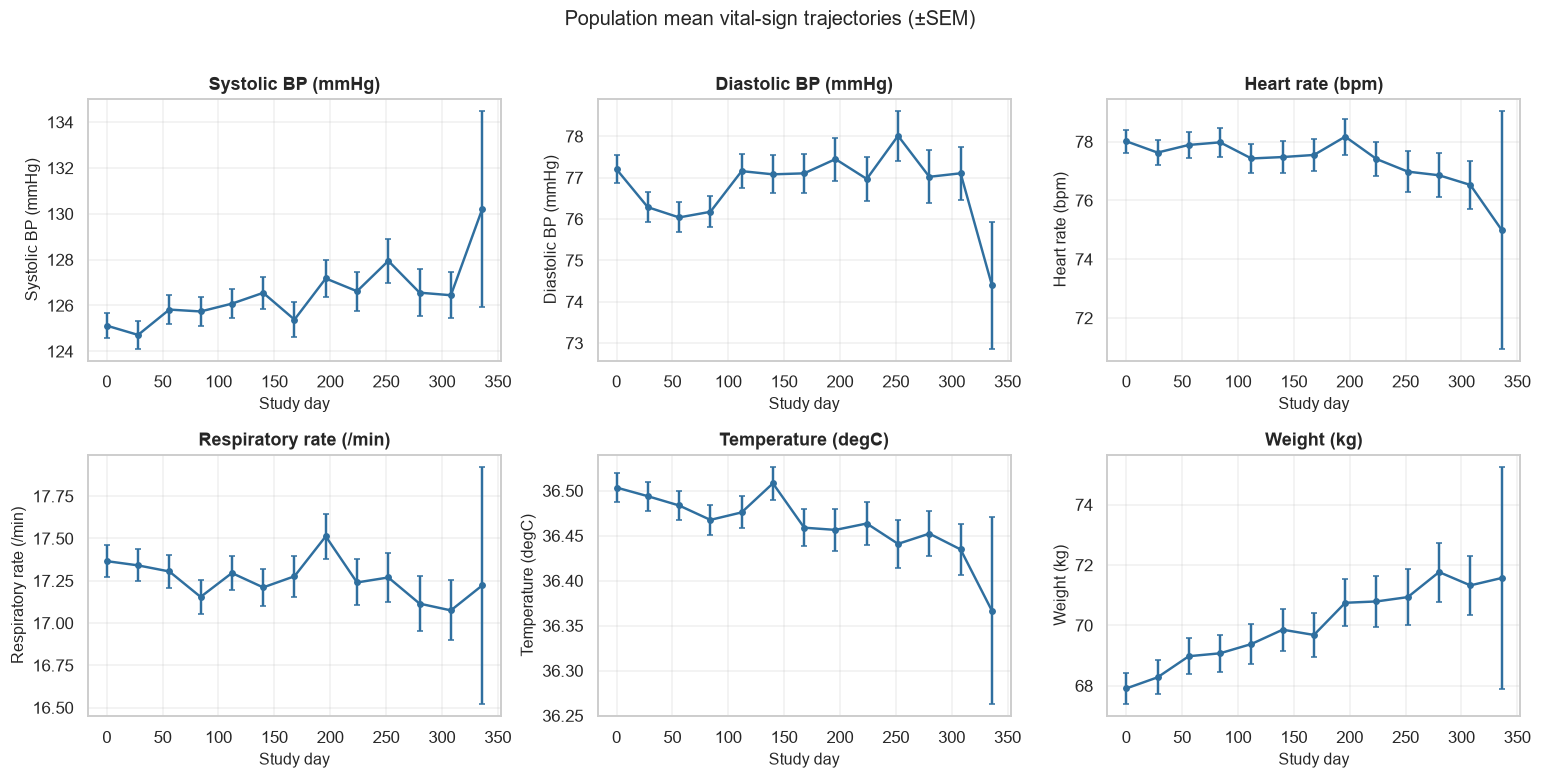

In [14]:
v = vitals[vitals["day"].between(0, CFG.landmark_max_day)].copy()
v["bin"] = (v["day"] // 28 * 28)

fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0))
for ax, col, label in zip(axes.ravel(),
                          ["sbp", "dbp", "hr", "rr", "temp", "weight"],
                          ["Systolic BP (mmHg)", "Diastolic BP (mmHg)",
                           "Heart rate (bpm)", "Respiratory rate (/min)",
                           "Temperature (degC)", "Weight (kg)"]):
    prof = v.groupby("bin")[col].agg(["mean", "sem"])
    ax.errorbar(prof.index, prof["mean"], yerr=prof["sem"], marker="o", ms=3.5,
                lw=1.6, capsize=2, color=plots.PALETTE[0])
    ax.set(xlabel="Study day", ylabel=label, title=label)
fig.suptitle("Population mean vital-sign trajectories (±SEM)", y=1.01, fontsize=13)
fig.tight_layout()
plots.save(fig, "02_vitals_trajectories")
plt.show()

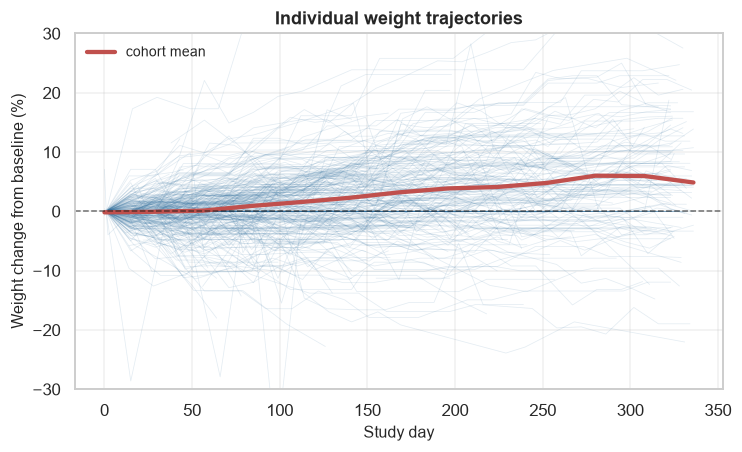

In [15]:
# Individual weight trajectories relative to baseline - a marker of deterioration.
w = vitals.merge(timeline[["PID", "first_dose_day"]], on="PID", how="left")
base_w = w[w["day"] <= w["first_dose_day"]].groupby("PID")["weight"].last().rename("w0")
w = w.merge(base_w, on="PID", how="left")
w["pct_change"] = 100 * (w["weight"] - w["w0"]) / w["w0"]
w = w[w["day"].between(0, CFG.landmark_max_day)]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
for pid, sub in w.groupby("PID"):
    if len(sub) > 4:
        ax.plot(sub["day"], sub["pct_change"], lw=0.5, alpha=0.13, color=plots.PALETTE[0])
prof = w.groupby(w["day"] // 28 * 28)["pct_change"].mean()
ax.plot(prof.index, prof.to_numpy(), lw=2.8, color=plots.PALETTE[1], label="cohort mean")
ax.axhline(0, ls="--", c="k", lw=1, alpha=0.6)
ax.set(xlabel="Study day", ylabel="Weight change from baseline (%)",
       title="Individual weight trajectories", ylim=(-30, 30))
ax.legend(fontsize=9)
plots.save(fig, "02_weight_trajectories")
plt.show()


### 4.3 Safety laboratory trajectories

The laboratory panel is the most densely sampled longitudinal source in the study. Two
things matter for the temporal design: whether the analytes *move* during treatment, and
whether that movement is large enough to separate patients. Both are visible below.


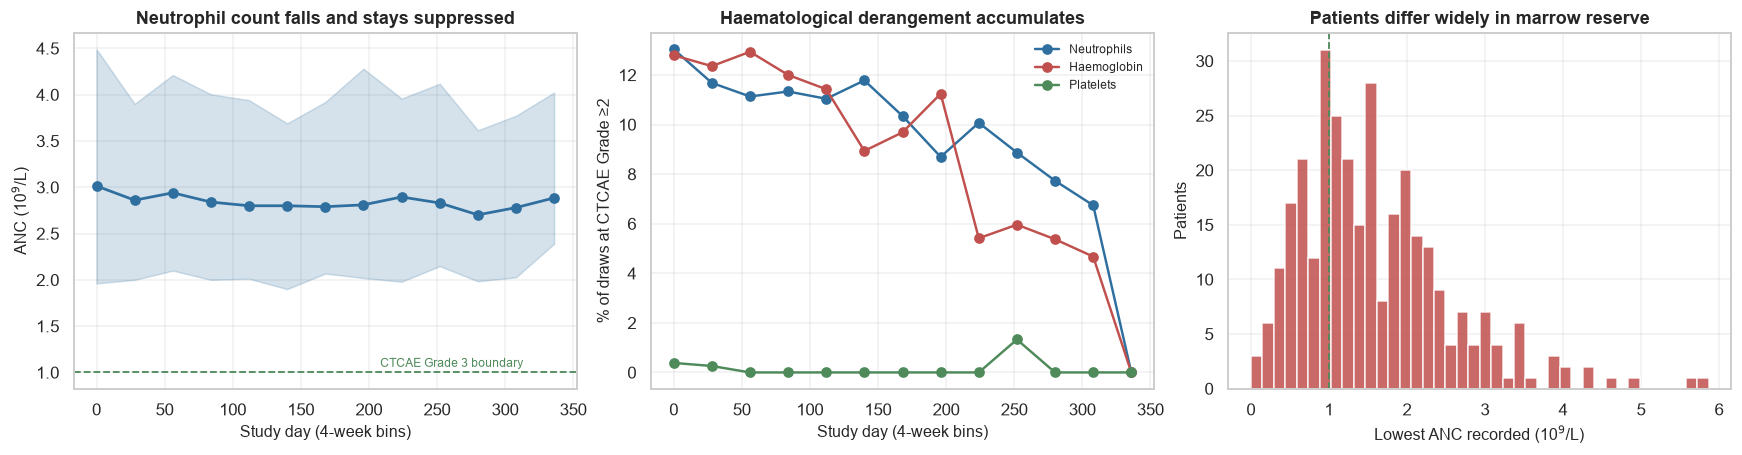

Patients ever reaching a Grade >=3 ANC : 96
Median lowest ANC per patient          : 1.44 x10^9/L


In [16]:
lab = io.tidy_lab(domains["lab_safe"])
lab_on = lab[lab["day"].between(0, CFG.landmark_max_day)].copy()
lab_on["bin"] = (lab_on["day"] // 28 * 28)

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.3))

# --- ANC: level over time, with the CTCAE Grade 3 boundary ---------------------------
anc = lab_on[lab_on["analyte"].eq("anc")].dropna(subset=["value"])
prof = anc.groupby("bin")["value"].agg(["median", "size"])
q = anc.groupby("bin")["value"].quantile([0.25, 0.75]).unstack()
axes[0].plot(prof.index, prof["median"], marker="o", lw=1.8, color=plots.PALETTE[0])
axes[0].fill_between(q.index, q[0.25], q[0.75], alpha=0.20, color=plots.PALETTE[0])
axes[0].axhline(1.0, color=plots.PALETTE[2], ls="--", lw=1.2)
axes[0].text(CFG.landmark_max_day * 0.62, 1.06, "CTCAE Grade 3 boundary",
             fontsize=8, color=plots.PALETTE[2])
axes[0].set(xlabel="Study day (4-week bins)", ylabel="ANC (10$^9$/L)",
            title="Neutrophil count falls and stays suppressed")

# --- share of draws that are severely deranged, by analyte ---------------------------
for code, name in [("anc", "Neutrophils"), ("hgb", "Haemoglobin"), ("plt", "Platelets")]:
    s = lab_on[lab_on["analyte"].eq(code) & lab_on["ctcae"].notna()]
    r = s.groupby("bin")["ctcae"].apply(lambda x: 100 * (x >= 2).mean())
    axes[1].plot(r.index, r.to_numpy(), marker="o", lw=1.6, label=name)
axes[1].set(xlabel="Study day (4-week bins)", ylabel="% of draws at CTCAE Grade ≥2",
            title="Haematological derangement accumulates")
axes[1].legend(fontsize=8)

# --- between-patient spread in the nadir: the variation a model can exploit ----------
nadir = (lab[lab["analyte"].eq("anc") & lab["day"].between(0, CFG.landmark_max_day)]
         .dropna(subset=["value"]).groupby("PID")["value"].min())
axes[2].hist(nadir[nadir < 8], bins=40, color=plots.PALETTE[1], alpha=0.85)
axes[2].axvline(1.0, color=plots.PALETTE[2], ls="--", lw=1.2)
axes[2].set(xlabel="Lowest ANC recorded (10$^9$/L)", ylabel="Patients",
            title="Patients differ widely in marrow reserve")

fig.tight_layout()
plots.save(fig, "02_lab_trajectories")
plt.show()

print(f"Patients ever reaching a Grade >=3 ANC : "
      f"{lab.query('analyte == \"anc\" and ctcae >= 3')['PID'].nunique()}")
print(f"Median lowest ANC per patient          : {nadir.median():.2f} x10^9/L")



### 4.4 Treatment exposure and dose intensity

Dose reduction is both a *consequence* of toxicity and a *predictor* of further toxicity
(a patient whose dose was cut is a patient who was not tolerating treatment). Relative
dose intensity is therefore one of the auxiliary exposure features required by the
project objectives.

In [17]:
dose_summary = (td.dropna(subset=["dose"])
                  .groupby("drug_group")
                  .agg(n_records=("dose", "size"), n_patients=("PID", "nunique"),
                       median_dose=("dose", "median"), max_cycle=("cycle", "max")))
print("Study treatment components (TESTDRUG.DRGNAME grouped):")
display(dose_summary)
print("\nThe blinded component is uniformly zero: only the placebo arm was released.")

Study treatment components (TESTDRUG.DRGNAME grouped):


,n_records,n_patients,median_dose,max_cycle
drug_group,,,,
blinded,2048,378,0.0000,13
fluorouracil,10505,379,"1,350.0000",15
irinotecan,5246,379,307.8000,15
leucovorin,5276,379,625.0000,15



The blinded component is uniformly zero: only the placebo arm was released.


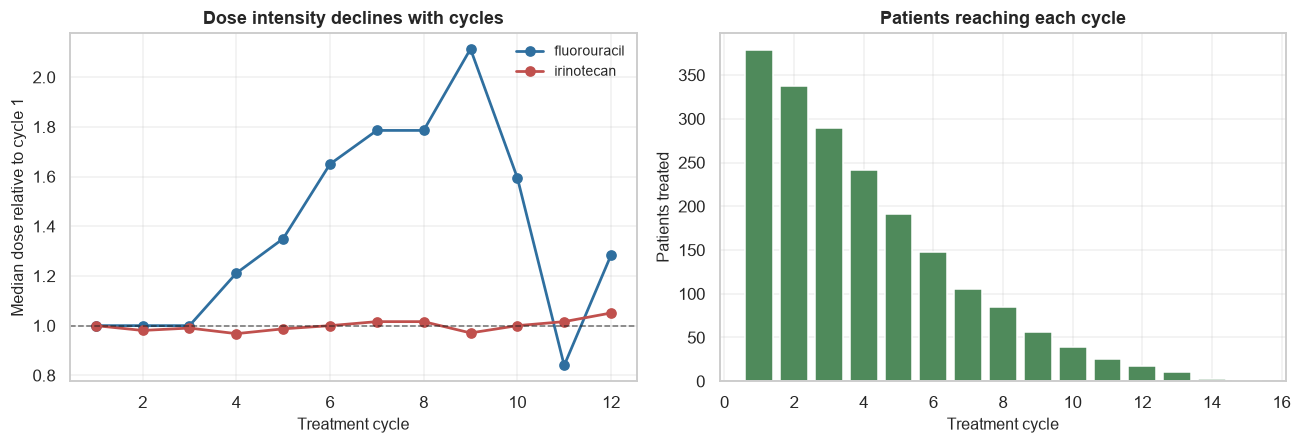

In [18]:
active = td[td["drug_group"].isin(["fluorouracil", "irinotecan"]) & td["dose"].notna()]
per_cycle = (active.groupby(["drug_group", "cycle"])["dose"]
                   .agg(["median", "size"]).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
for drug, colour in zip(["fluorouracil", "irinotecan"], plots.PALETTE[:2]):
    sub = per_cycle[(per_cycle["drug_group"] == drug) & (per_cycle["cycle"] <= 12)]
    axes[0].plot(sub["cycle"], sub["median"] / sub["median"].iloc[0], marker="o",
                 lw=1.8, color=colour, label=drug)
axes[0].axhline(1.0, ls="--", c="k", lw=1, alpha=0.6)
axes[0].set(xlabel="Treatment cycle", ylabel="Median dose relative to cycle 1",
            title="Dose intensity declines with cycles")
axes[0].legend(fontsize=9)

n_per_cycle = active.groupby("cycle")["PID"].nunique()
axes[1].bar(n_per_cycle.index, n_per_cycle.to_numpy(), color=plots.PALETTE[2])
axes[1].set(xlabel="Treatment cycle", ylabel="Patients treated",
            title="Patients reaching each cycle")

fig.tight_layout()
plots.save(fig, "02_dose_intensity")
plt.show()


## 5. The target variable

The registered primary target is **any treatment-emergent Grade ≥3 adverse event within a
forward window of 30 days**. The mid-semester report explicitly left the horizon
"subject to data-driven confirmation", so this section quantifies the trade-off.

In [19]:
from dataclasses import replace

horizons = [14, 21, 30, 45, 60, 90]
rows = []
for h in horizons:
    cfg_h = replace(CFG, prediction_horizon_days=h)
    grid_h = labels.make_landmark_grid(timeline, cfg_h)
    lm_h = labels.landmark_label(grid_h, ae, timeline, cfg_h)
    static_h = labels.static_label(ae, timeline, cfg_h)
    rows.append({
        "horizon_days": h,
        "landmark_rows": len(lm_h),
        "landmark_event_rate": round(lm_h["y"].mean(), 4),
        "rows_dropped_censored": len(grid_h) - len(lm_h),
        "static_event_rate": round(static_h.query("informative")["y"].mean(), 4),
    })
horizon_tbl = pd.DataFrame(rows)
horizon_tbl.to_csv(TABLE_DIR / "02_horizon_sensitivity.csv", index=False)
horizon_tbl

,horizon_days,landmark_rows,landmark_event_rate,rows_dropped_censored,static_event_rate
0,14,5862,0.0773,51,0.1032
1,21,5767,0.1164,146,0.1825
2,30,5656,0.1605,257,0.2302
3,45,5435,0.2182,478,0.2891
4,60,5197,0.2713,716,0.3569
5,90,4830,0.3613,1083,0.4432


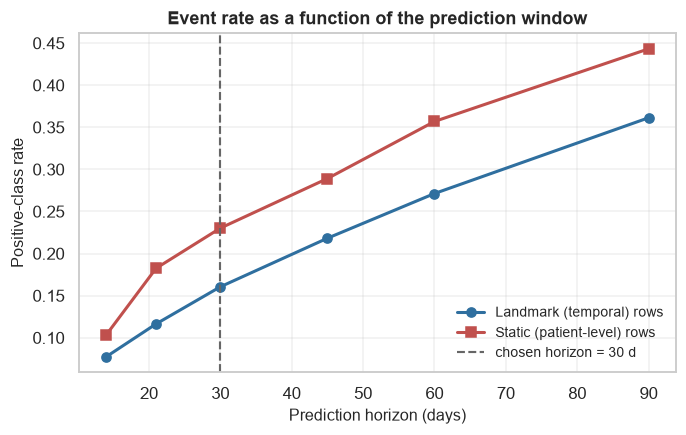

In [20]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(horizon_tbl["horizon_days"], horizon_tbl["landmark_event_rate"], marker="o",
        lw=2, color=plots.PALETTE[0], label="Landmark (temporal) rows")
ax.plot(horizon_tbl["horizon_days"], horizon_tbl["static_event_rate"], marker="s",
        lw=2, color=plots.PALETTE[1], label="Static (patient-level) rows")
ax.axvline(CFG.prediction_horizon_days, ls="--", c="0.4", lw=1.4,
           label=f"chosen horizon = {CFG.prediction_horizon_days} d")
ax.set(xlabel="Prediction horizon (days)", ylabel="Positive-class rate",
       title="Event rate as a function of the prediction window")
ax.legend(fontsize=9)
plots.save(fig, "02_horizon_sensitivity")
plt.show()


**Decision.** The 30-day horizon is retained. It yields a positive rate of roughly 16% at
the landmark level — enough events for stable estimation without the class balance becoming
degenerate — while remaining short enough to be clinically actionable (roughly one FOLFIRI
cycle plus its nadir). Shorter windows (14 days) make the class extremely rare; longer
windows (60–90 days) approach an "ever/never" outcome and lose the forward-looking
character that distinguishes this work from conventional safety reporting.

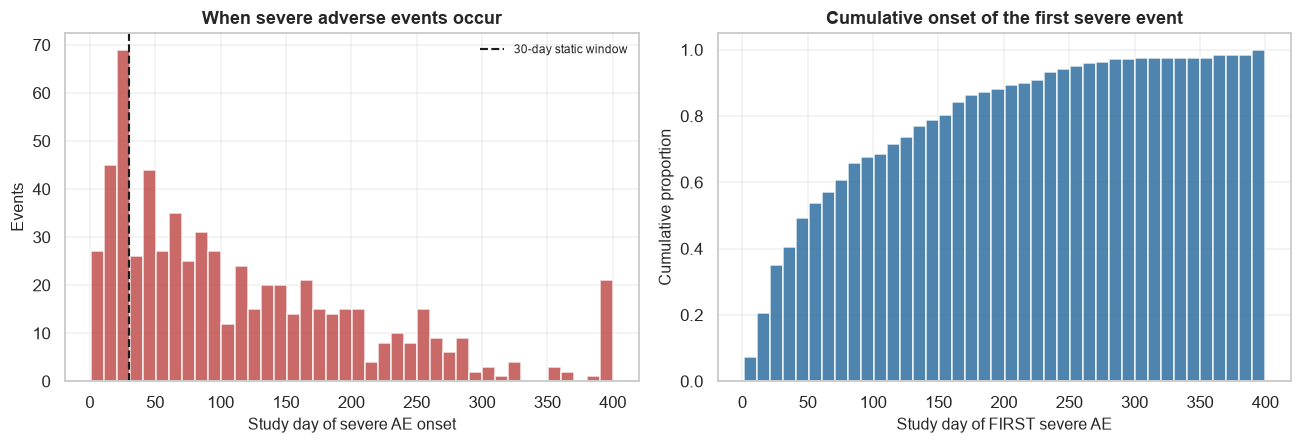

Median day of first severe AE: 54
Proportion of first severe events occurring after day 30: 64.9%


In [21]:
# Where do the severe events fall relative to the start of treatment?
sev = labels.severe_events(te)
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

axes[0].hist(sev["start_day"].clip(upper=400), bins=40, color=plots.PALETTE[1], alpha=0.85)
axes[0].axvline(CFG.prediction_horizon_days, ls="--", c="k", lw=1.4,
                label=f"{CFG.prediction_horizon_days}-day static window")
axes[0].set(xlabel="Study day of severe AE onset", ylabel="Events",
            title="When severe adverse events occur")
axes[0].legend(fontsize=8)

first_sev = sev.groupby("PID")["start_day"].min()
axes[1].hist(first_sev.clip(upper=400), bins=40, color=plots.PALETTE[0], alpha=0.85,
             cumulative=True, density=True)
axes[1].set(xlabel="Study day of FIRST severe AE", ylabel="Cumulative proportion",
            title="Cumulative onset of the first severe event")

fig.tight_layout()
plots.save(fig, "02_severe_ae_timing")
plt.show()

print(f"Median day of first severe AE: {first_sev.median():.0f}")
print(f"Proportion of first severe events occurring after day 30: "
      f"{(first_sev > 30).mean():.1%}")


This is the single most important exploratory result for the dissertation: **a large
majority of first severe events occur after day 30**, i.e. *outside* the window that a
purely baseline (static) model is able to address. Predicting them requires a model that
is re-evaluated as the trial progresses — the temporal design.

---

## Summary of this notebook

| Evidence | Implication |
|---|---|
| Severe-AE hazard varies markedly across the trial, peaking in the first two cycles | A single baseline score is inadequate |
| Severe events **recur** (median 2 per affected patient) | Time-to-first-event survival analysis is insufficient; a repeated forward-window target is required |
| Most first severe events occur **after** day 30 | The static baseline model addresses only a minority of the clinical problem |
| ECOG deteriorates and dose intensity falls with time | Genuine time-varying predictors exist in the data |
| Neutrophil counts fall early and stay suppressed, and patients differ widely in nadir | The laboratory panel supplies a directly measured, strongly time-varying predictor |
| 30-day horizon gives ~16% positive rate at landmark level | Retained as the primary target |
